In [47]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Evaluation metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Tesla Deliveries Forecasting Using Machine Learning

## Objective

The objective of this project is to predict Tesla vehicle deliveries using historical production, pricing, battery specifications, charging infrastructure, and regional information.

## Workflow

1. Data Preprocessing
2. Exploratory Data Analysis (EDA)
3. Feature Engineering
4. Linear Regression
5. Random Forest Regression
6. Hyperparameter Tuning
7. Model Comparison
8. Conclusion

In [48]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv
/kaggle/input/datasets/vaibhavnama/tesla-dataset/tesla_deliveries_dataset_2015_2025.csv


In [49]:
import pandas as pd

df = pd.read_csv(
    "/kaggle/input/datasets/vaibhavnama/tesla-dataset/tesla_deliveries_dataset_2015_2025.csv"
)

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [50]:
print(df.shape)
df.head()

(2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [51]:
# Dataset overview

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

df.head()

Shape: (2640, 12)

Columns:
Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')

Missing Values:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [52]:
# Check missing values in each column

print("Missing Values:\n")
print(df.isnull().sum())

Missing Values:

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


In [53]:
# Check duplicate rows

duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [54]:
# Display data types

print(df.dtypes)

Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object


In [55]:
# Define target variable

y = df["Estimated_Deliveries"]

# Define input features

X = df.drop("Estimated_Deliveries", axis=1)

print(X.shape)
print(y.shape)

(2640, 11)
(2640,)


In [56]:
# Convert month into quarter

df["Quarter"] = ((df["Month"] - 1) // 3) + 1

In [57]:
# Create time-based feature

df["Years_Since_2015"] = df["Year"] - 2015

In [58]:
# Convert categorical columns into numerical format

df = pd.get_dummies(
    df,
    columns=["Region", "Model", "Source_Type"],
    drop_first=True
)

print(df.shape)

(2640, 20)


In [59]:
# Features

X = df.drop("Estimated_Deliveries", axis=1)

# Target

y = df["Estimated_Deliveries"]

In [60]:
from sklearn.model_selection import train_test_split

# Split dataset into train and test sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (2112, 19)
Testing Shape: (528, 19)


In [61]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler

scaler = StandardScaler()

# Fit on training data and transform

X_train_scaled = scaler.fit_transform(X_train)

# Transform testing data

X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(2112, 19)
(528, 19)


In [62]:
# Summary statistics

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,2640.0,2020.000000,3.162877,2015.00,2017.000,2020.000,2023.0000,2025.00
Month,2640.0,6.500000,3.452707,1.00,3.750,6.500,9.2500,12.00
Estimated_Deliveries,2640.0,9922.199621,3935.950093,48.00,7292.000,9857.000,12510.2500,25704.00
Production_Units,2640.0,10655.847348,4260.600858,50.00,7828.250,10546.500,13469.0000,28939.00
Avg_Price_USD,2640.0,84907.340330,20123.258036,50003.70,67726.365,85058.510,102373.0425,119965.36
Battery_Capacity_kWh,2640.0,87.059470,20.836265,60.00,75.000,82.000,100.0000,120.00
Range_km,2640.0,500.257576,120.868549,330.00,418.000,470.000,586.2500,719.00
CO2_Saved_tons,2640.0,744.076989,353.221224,3.07,499.620,699.515,943.7650,2548.55
Charging_Stations,2640.0,8932.133712,3469.565883,3002.00,5897.750,8901.500,11938.0000,14996.00
Quarter,2640.0,2.500000,1.118246,1.00,1.750,2.500,3.2500,4.00


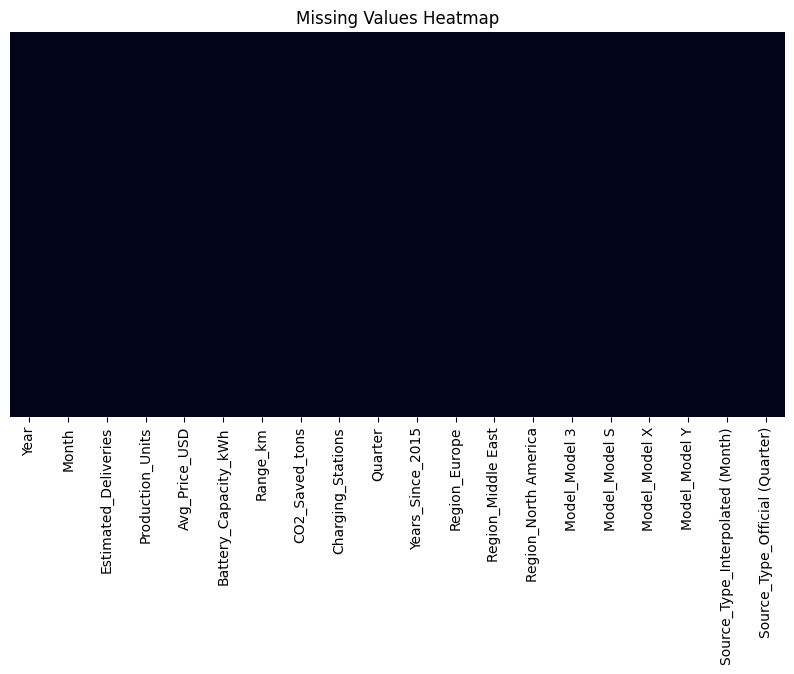

In [63]:
# Missing values check

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values Heatmap")

plt.show()

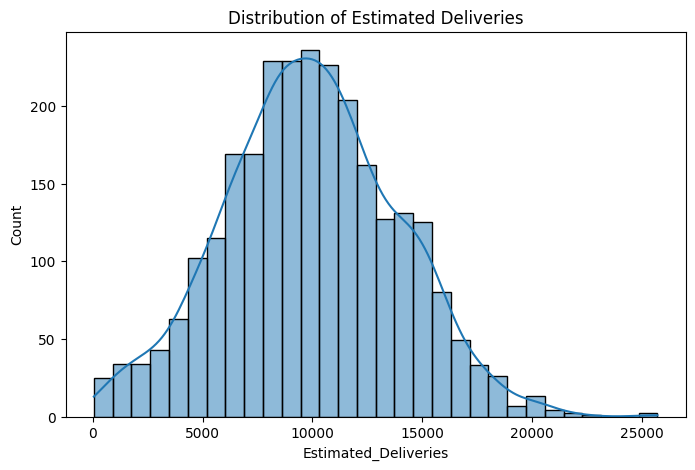

In [64]:
# Distribution of Estimated Deliveries

plt.figure(figsize=(8,5))

sns.histplot(
    df["Estimated_Deliveries"],
    bins=30,
    kde=True
)

plt.title("Distribution of Estimated Deliveries")

plt.show()

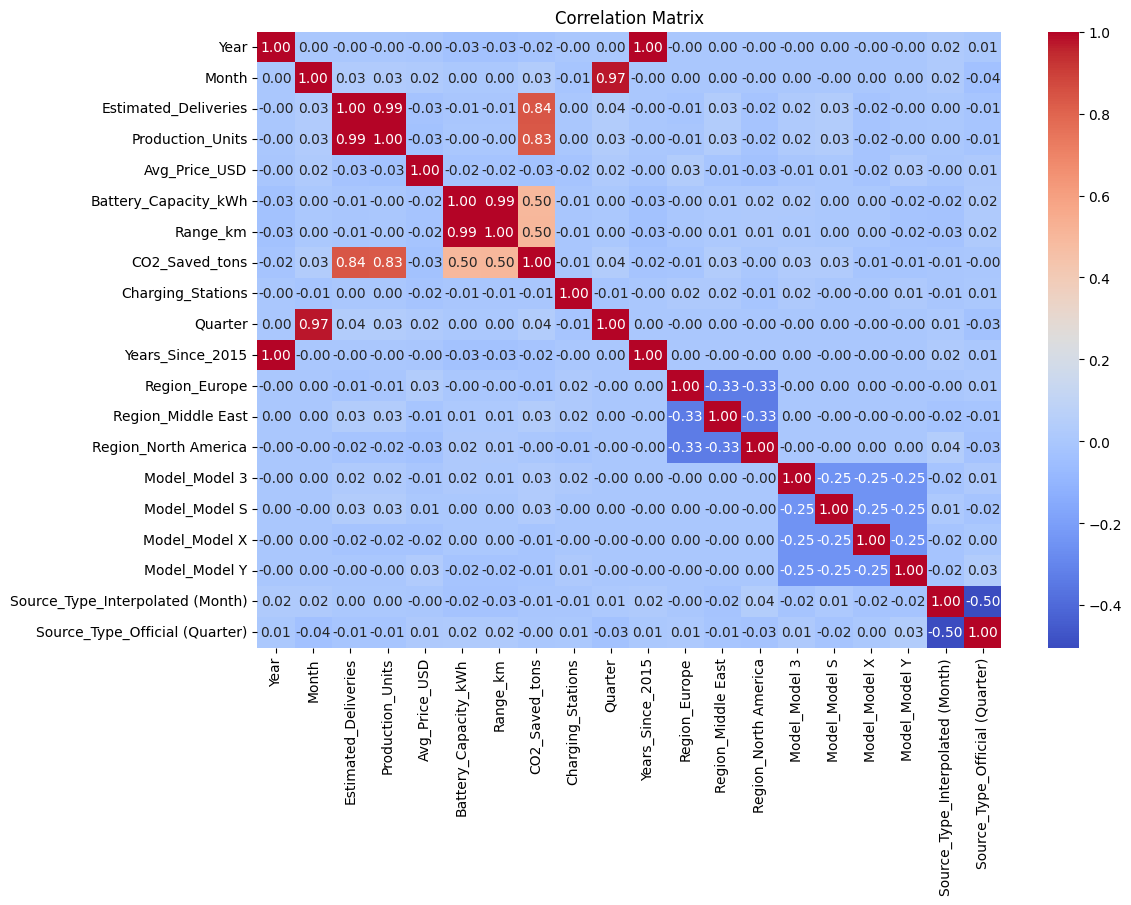

In [65]:
# Correlation analysis

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [66]:
print(df.columns.tolist())

['Year', 'Month', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations', 'Quarter', 'Years_Since_2015', 'Region_Europe', 'Region_Middle East', 'Region_North America', 'Model_Model 3', 'Model_Model S', 'Model_Model X', 'Model_Model Y', 'Source_Type_Interpolated (Month)', 'Source_Type_Official (Quarter)']


In [67]:
# Dataset shape and columns

print("Shape:", df.shape)

print("\nColumns:")
for col in df.columns:
    print(col)

Shape: (2640, 20)

Columns:
Year
Month
Estimated_Deliveries
Production_Units
Avg_Price_USD
Battery_Capacity_kWh
Range_km
CO2_Saved_tons
Charging_Stations
Quarter
Years_Since_2015
Region_Europe
Region_Middle East
Region_North America
Model_Model 3
Model_Model S
Model_Model X
Model_Model Y
Source_Type_Interpolated (Month)
Source_Type_Official (Quarter)


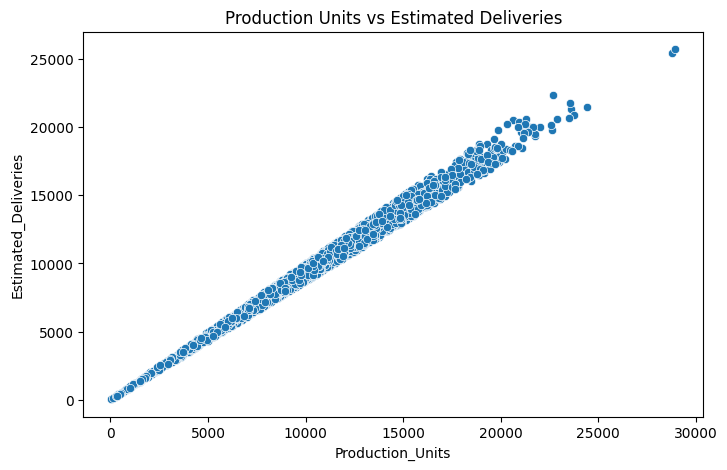

In [68]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Production_Units",
    y="Estimated_Deliveries"
)

plt.title("Production Units vs Estimated Deliveries")
plt.show()

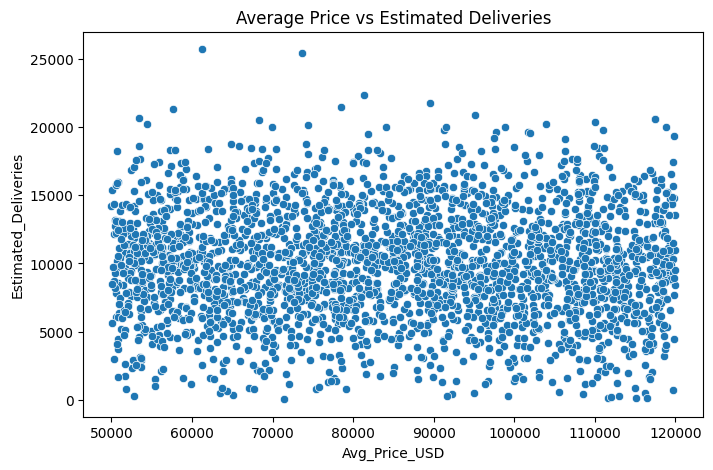

In [69]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Avg_Price_USD",
    y="Estimated_Deliveries"
)

plt.title("Average Price vs Estimated Deliveries")
plt.show()

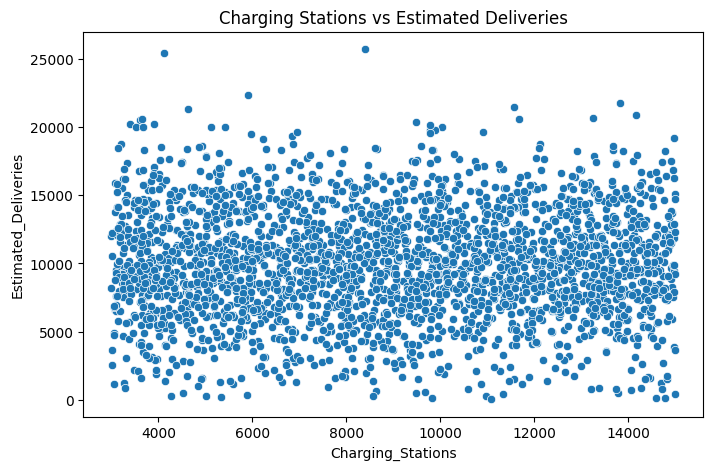

In [70]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Charging_Stations",
    y="Estimated_Deliveries"
)

plt.title("Charging Stations vs Estimated Deliveries")
plt.show()

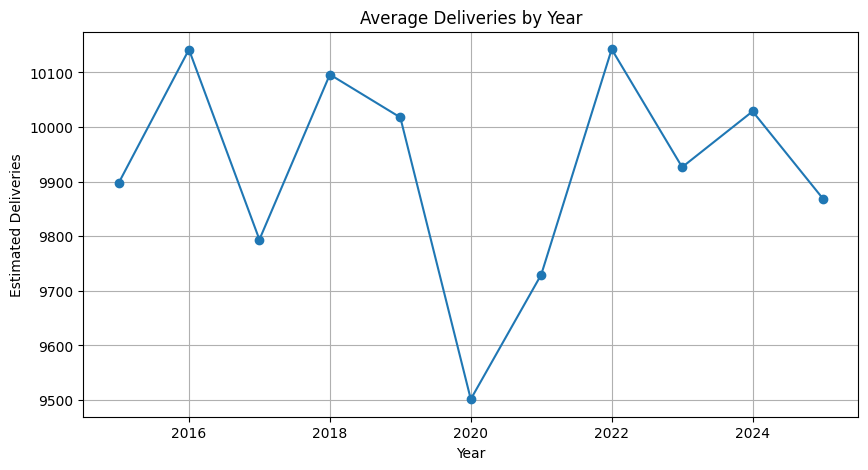

In [71]:
yearly = df.groupby("Year")["Estimated_Deliveries"].mean()

plt.figure(figsize=(10,5))

yearly.plot(marker="o")

plt.title("Average Deliveries by Year")
plt.ylabel("Estimated Deliveries")

plt.grid(True)
plt.show()

# Feature Engineering

Feature engineering is performed to create new meaningful features from existing variables. These features help machine learning models capture hidden patterns and improve predictive performance.

In [72]:
# Create quarter from month

df["Quarter"] = ((df["Month"] - 1) // 3) + 1

df[["Month", "Quarter"]].head()

,Month,Quarter
0,5,2
1,2,1
2,1,1
3,2,1
4,12,4


In [73]:
# Years elapsed since 2015

df["Years_Since_2015"] = df["Year"] - 2015

df[["Year", "Years_Since_2015"]].head()

,Year,Years_Since_2015
0,2023,8
1,2015,0
2,2019,4
3,2021,6
4,2016,1


In [74]:
# Cost efficiency feature

df["Price_Per_KM"] = (
    df["Avg_Price_USD"] /
    df["Range_km"]
)

df[["Avg_Price_USD", "Range_km", "Price_Per_KM"]].head()

,Avg_Price_USD,Range_km,Price_Per_KM
0,92874.27,704,131.923679
1,62205.65,438,142.022032
2,117887.32,480,245.598583
3,89294.91,712,125.414199
4,114846.78,661,173.747020


In [75]:
# Range generated per battery capacity

df["Battery_Efficiency"] = (
    df["Range_km"] /
    df["Battery_Capacity_kWh"]
)

df[["Range_km", "Battery_Capacity_kWh", "Battery_Efficiency"]].head()

,Range_km,Battery_Capacity_kWh,Battery_Efficiency
0,704,120,5.866667
1,438,75,5.840000
2,480,82,5.853659
3,712,120,5.933333
4,661,120,5.508333


In [76]:
# Charging stations relative to production

df["Charging_Production_Ratio"] = (
    df["Charging_Stations"] /
    df["Production_Units"]
)

df[["Charging_Stations",
    "Production_Units",
    "Charging_Production_Ratio"]].head()

,Charging_Stations,Production_Units,Charging_Production_Ratio
0,12207,17922,0.681118
1,7640,4164,1.834774
2,14071,9189,1.531287
3,9333,7311,1.276570
4,8722,13537,0.644308


## Feature Engineering Summary

The following engineered features were created:

- Quarter
- Years_Since_2015
- Price_Per_KM
- Battery_Efficiency
- Charging_Production_Ratio

These features help capture temporal trends, vehicle efficiency, pricing characteristics, and charging infrastructure influence on Tesla deliveries.

# Linear Regression Model

Linear Regression is used as a baseline regression algorithm to predict Tesla vehicle deliveries. It establishes a linear relationship between the target variable and the input features.

In [77]:
# Features and target variable

X = df.drop("Estimated_Deliveries", axis=1)

y = df["Estimated_Deliveries"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (2640, 22)
Target Shape: (2640,)


In [78]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (2112, 22)
Testing Shape: (528, 22)


In [79]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler

scaler = StandardScaler()

# Fit and transform training data

X_train_scaled = scaler.fit_transform(X_train)

# Transform testing data

X_test_scaled = scaler.transform(X_test)

In [80]:
from sklearn.linear_model import LinearRegression

# Initialize model

lr = LinearRegression()

# Train model

lr.fit(X_train_scaled, y_train)

LinearRegression()

In [81]:
# Generate predictions

y_pred_lr = lr.predict(X_test_scaled)

# Display first few predictions

print(y_pred_lr[:10])

[ 7590.09583045  9424.71362867  8790.57029723  9368.39246147
  8923.14289599 11471.1851589  14210.38257365 14335.78331697
 10013.26438089  7864.35621547]


In [82]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

# Evaluation metrics

r2 = r2_score(y_test, y_pred_lr)

mae = mean_absolute_error(y_test, y_pred_lr)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_lr)
)

print("R² Score :", round(r2,4))
print("MAE      :", round(mae,4))
print("RMSE     :", round(rmse,4))

R² Score : 0.9901
MAE      : 309.3778
RMSE     : 383.9331


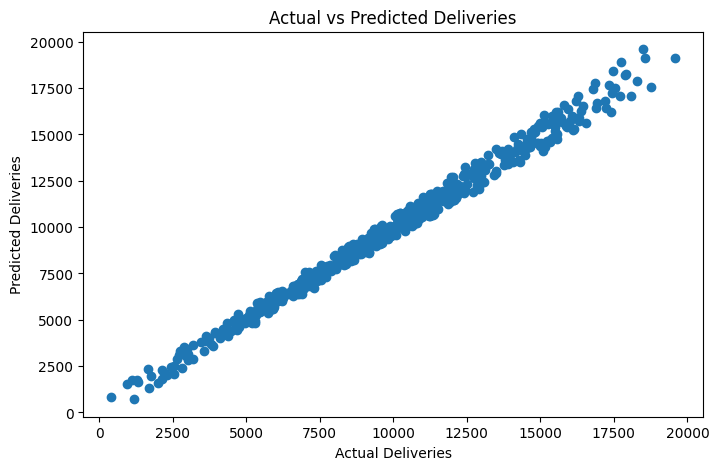

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred_lr)

plt.xlabel("Actual Deliveries")
plt.ylabel("Predicted Deliveries")

plt.title("Actual vs Predicted Deliveries")

plt.show()

## Linear Regression Summary

The Linear Regression model serves as a baseline model for delivery prediction. Its performance provides a benchmark against which more advanced ensemble methods such as Random Forest and XGBoost can be compared.

# Hyperparameter Tuning

Hyperparameter tuning is performed to find the optimal combination of Random Forest parameters that maximizes predictive performance and improves model generalization.

In [84]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# Parameter grid

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Base model

rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

# Grid Search

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5, estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='r2', verbose=1)

In [85]:
best_rf = grid_search.best_estimator_

y_pred_best = best_rf.predict(X_test)

In [86]:
# Define features and target

X = df.drop("Estimated_Deliveries", axis=1)
y = df["Estimated_Deliveries"]

# Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (2112, 22)
X_test : (528, 22)
y_train: (2112,)
y_test : (528,)


In [87]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20],
    "min_samples_split": [2, 5]
}

rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}


In [88]:
# Best model from Grid Search

best_rf = grid_search.best_estimator_

# Predictions

y_pred_best = best_rf.predict(X_test)

In [89]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

# Evaluation metrics

best_r2 = r2_score(y_test, y_pred_best)

best_mae = mean_absolute_error(y_test, y_pred_best)

best_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_best)
)

print("R² Score :", round(best_r2,4))
print("MAE      :", round(best_mae,4))
print("RMSE     :", round(best_rmse,4))

R² Score : 0.9885
MAE      : 328.9709
RMSE     : 414.0305


## Hyperparameter Tuning Results

Grid Search Cross Validation was used to identify the optimal Random Forest configuration.

Best Parameters:
- Max Depth = 20
- Min Samples Split = 2
- Number of Trees = 20

The tuned model was then evaluated on the test dataset using R² Score, MAE, and RMSE.

# Model Comparison and Conclusion

Two regression models were evaluated for predicting Tesla vehicle deliveries:

| Model | R² Score | MAE | RMSE |
|---------|---------:|---------:|---------:|
| Linear Regression | 0.9901 | 309.38 | 383.93 |
| Tuned Random Forest | 0.9885 | 328.97 | 414.03 |

## Conclusion

Linear Regression achieved the best overall performance with the highest R² Score and the lowest prediction errors.

The results indicate that Tesla delivery estimates in this dataset exhibit strong linear relationships with production, pricing, battery specifications, charging infrastructure, and temporal features.

Therefore, Linear Regression was selected as the final model for delivery prediction.